# OOD evaluation: 14 in-house + 6 baseline detectors on clean and humanized arxiv, with humanizer attack analysis

Publication-quality companion to [models/val_results.ipynb](val_results.ipynb) (in-distribution) and to [docs/RESEARCH_REPORT.md §3.2 and §3.3](../docs/RESEARCH_REPORT.md). All headline tables are reproduced from the authoritative artefacts:

- [`test/results/arxiv_eval/summary_clean.csv`](../test/results/arxiv_eval/summary_clean.csv) and [`summary_humanized.csv`](../test/results/arxiv_eval/summary_humanized.csv) — the 20-detector unified leaderboard produced by [`test/evaluate_arxiv.py`](../test/evaluate_arxiv.py).
- [`per_source_clean.csv`](../test/results/arxiv_eval/per_source_clean.csv), [`per_source_humanized.csv`](../test/results/arxiv_eval/per_source_humanized.csv) — per-humanizer per-detector AI catch rates.
- The per-detector baseline JSONs under [`models/baseline_results/arxiv_clean/`](baseline_results/arxiv_clean/) and [`models/baseline_results/arxiv_humanized/`](baseline_results/arxiv_humanized/) — used for the more granular per-source numbers (DetectGPT, RADAR, R-Detect) that the strict-FPR-thresholded summary CSVs cannot express.

## Scope and caveats

1. **Double OOD shift.** The arxiv corpus shifts both axes versus training: *domain* (USE student essays → academic abstracts) and *LLM family* (open-source 7-8B rewriters → Claude-haiku, per [docs/AI_MODELS_USED.md](../docs/AI_MODELS_USED.md)). This is more aggressive than the field's typical one-axis shift.
2. **Two evaluation sets.** Clean ([`data/testing_dataset/arxiv_final/arxiv_merged.jsonl`](../data/testing_dataset/arxiv_final/arxiv_merged.jsonl)) has **n = 2 574** = 1 287 human + 1 287 Claude-haiku rewrites. Humanized ([`arxiv_eval_with_humanizers.jsonl`](../data/testing_dataset/arxiv_final/arxiv_eval_with_humanizers.jsonl)) has **n = 3 861** = 1 287 human + 1 287 Adv-P + 1 287 TempParaphraser (per [`test/results/arxiv_eval/REPORT.md` §1](../test/results/arxiv_eval/REPORT.md)).
3. **Strict FPR ≤ 1 % is the headline operating regime** ([METHODOLOGY.md §6.2](../METHODOLOGY.md), [docs/RESEARCH_REPORT.md §4.3](../docs/RESEARCH_REPORT.md)). Both default-threshold and strict-FPR tables are reported because the ranking changes substantially between them — this is the §1.5 finding of the research report.
4. **AUC_eff = max(AUC, 1 − AUC)** is the sign-flip-corrected ranking quality, motivated by the §1.6 observation that Binoculars (GPT-2 pair) and `classical_svm` invert score direction on academic prose.
5. **Twenty detectors total:** 14 in-house from [`models/ready_models/`](ready_models/) (4 fusion + 10 classical) + 6 baselines from [`test/baselines/`](../test/baselines/) (DetectGPT, Fast-DetectGPT, Binoculars, R-Detect, RADAR, RAIDAR). Baselines were run at the configurations recorded in their respective `.metrics.json::config` blocks (small-model local for several; see [docs/AI_MODELS_USED.md §4](../docs/AI_MODELS_USED.md)).

In [1]:
# Setup -- mirrors models/val_results.ipynb cell-1 plus the baseline JSON loader
# used by the side-by-side cells of interim_results.ipynb (cells F.5b-F.6).
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from training.classical import ClassicalClassifier, select_blocks
from training.feature_dataset import FeatureNormalizer, FusionFeatureDataset
from training.model import FusionClassifier
from test.evaluate_arxiv import _predict_at_strict_fpr
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 14 in-house checkpoints
MODELS_DIR = ROOT / 'models/ready_models'
MODEL_NAMES = {
    'fusion_concat.pt':            'fusion_concat',
    'fusion_mlp.pt':               'fusion_mlp',
    'fusion_attention.pt':         'fusion_attention',
    'fusion_gating.pt':            'fusion_gating',
    'clf_logreg.joblib':           'classical_logreg',
    'clf_svm.joblib':              'classical_svm',
    'clf_mlp.joblib':              'classical_mlp',
    'clf_random_forest.joblib':    'classical_random_forest',
    'clf_xgboost.joblib':          'classical_xgboost',
    'clf_hist_gbm.joblib':         'classical_hist_gbm',
    'clf_gradient_boosting.joblib':'classical_gradient_boosting',
    'clf_random_forest_nela.joblib':  'classical_random_forest_nela',
    'clf_random_forest_style.joblib': 'classical_random_forest_style',
    'clf_random_forest_trace.joblib': 'classical_random_forest_trace',
}
MODELS = [(MODEL_NAMES[p.name], p)
          for p in sorted(list(MODELS_DIR.glob('*.pt')) + list(MODELS_DIR.glob('*.joblib')))
          if p.name in MODEL_NAMES]
assert len(MODELS) == 14

BASELINES = ['detect_gpt', 'fast_detect_gpt', 'binoculars', 'r_detect', 'radar', 'raidar']
ARXIV_NPZ_CLEAN = ROOT / 'data/features/arxiv.npz'
ARXIV_NPZ_HUM   = ROOT / 'data/features/arxiv_humanized.npz'
BASE_CLEAN_DIR  = ROOT / 'models/baseline_results/arxiv_clean'
BASE_HUM_DIR    = ROOT / 'models/baseline_results/arxiv_humanized'
EVAL_DIR        = ROOT / 'test/results/arxiv_eval'

def score_one(npz_path, ckpt_path):
    npz_path, ckpt_path = Path(npz_path), Path(ckpt_path)
    if ckpt_path.suffix == '.pt':
        model, payload = FusionClassifier.load(ckpt_path, map_location=DEVICE)
        norm = FeatureNormalizer.from_state_dict(payload.get('normalizer'))
        ds = FusionFeatureDataset(npz_path)
        if norm: ds.apply_normalizer(norm)
        model.eval().to(DEVICE)
        with torch.no_grad():
            logits = model(
                torch.from_numpy(ds.nela).to(DEVICE),
                torch.from_numpy(ds.style).to(DEVICE),
                torch.from_numpy(ds.trace).to(DEVICE),
            )
            scores = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        return ds.labels, scores, ds.sources if hasattr(ds, 'sources') else None
    clf, payload = ClassicalClassifier.load(ckpt_path)
    norm = FeatureNormalizer.from_state_dict(payload.get('normalizer'))
    ds = FusionFeatureDataset(npz_path)
    if norm: ds.apply_normalizer(norm)
    dims = payload.get('dims') or {'nela': 87, 'style': 10, 'trace': 128}
    blocks = tuple(b for b in ('nela', 'style', 'trace') if b in dims)
    X = select_blocks(ds.nela, ds.style, ds.trace, blocks)
    return ds.labels, clf.predict_proba(X)[:, 1], ds.sources if hasattr(ds, 'sources') else None

def load_baseline(json_path):
    """Read a `test/compare_baselines.py` JSON; return raw arrays + test block."""
    p = Path(json_path)
    if not p.exists():
        return None
    d = json.loads(p.read_text(encoding='utf-8'))
    return {
        'detector': d.get('detector'),
        'n': d.get('n_records'),
        'ids': [str(i) for i in (d.get('ids') or [])],
        'y_true': np.asarray(d.get('y_true') or []),
        'y_scores': np.asarray(d.get('y_scores') or []),
        'sources': d.get('sources') or [],
        'test': d.get('test') or {},
        'per_source_accuracy': d.get('per_source_accuracy') or {},
        'config': d.get('config'),
        'error': d.get('error'),
    }

print(f'Setup OK. Device={DEVICE}. {len(MODELS)} in-house checkpoints, {len(BASELINES)} baselines.')
print(f'Eval CSVs at {EVAL_DIR.relative_to(ROOT)}.')


Setup OK. Device=cuda. 14 in-house checkpoints, 6 baselines.
Eval CSVs at test\results\arxiv_eval.


## 1. Clean arxiv leaderboard, default threshold (`score >= 0.5`)

All 20 detectors on `arxiv_merged.jsonl` / `arxiv.npz`. n = 2 574 (1 287 human / 1 287 ai). Sorted by AUC_eff (= max(AUC, 1 − AUC)) descending. The `AUC_eff` column corrects for the sign-flip phenomenon documented in [docs/RESEARCH_REPORT.md §1.6](../docs/RESEARCH_REPORT.md): Binoculars (GPT-2 pair) and `classical_svm` invert score direction on academic prose, so their raw AUCs land below 0.5.

In [2]:
def _row_in_house_default(name, ckpt_path, npz_path):
    y, s, _ = score_one(npz_path, ckpt_path)
    yp = (s >= 0.5).astype(int)
    auc = roc_auc_score(y, s) if len(set(y.tolist())) > 1 else None
    return {
        'detector': name, 'kind': 'in-house', 'n': len(y),
        'AUC': auc,
        'AUC_eff': (1 - auc) if (auc is not None and auc < 0.5) else auc,
        'acc': accuracy_score(y, yp),
        'macroF1': f1_score(y, yp, average='macro', zero_division=0),
        'ROC-AUC': auc,
    }

def _row_baseline_default(d_name, base_dir, file_stub):
    j = load_baseline(base_dir / f'{file_stub}__{d_name}.metrics.json')
    if j is None or j.get('error'):
        return None
    y = j['y_true']; s = j['y_scores']
    if len(y) == 0:
        return None
    yp = (s >= 0.5).astype(int)
    auc = roc_auc_score(y, s) if len(set(y.tolist())) > 1 else None
    return {
        'detector': f'baseline_{d_name}', 'kind': 'baseline', 'n': len(y),
        'AUC': auc,
        'AUC_eff': (1 - auc) if (auc is not None and auc < 0.5) else auc,
        'acc': accuracy_score(y, yp),
        'macroF1': f1_score(y, yp, average='macro', zero_division=0),
        'ROC-AUC': auc,
    }

rows = [_row_in_house_default(n, p, ARXIV_NPZ_CLEAN) for n, p in MODELS]
rows += [r for r in (_row_baseline_default(b, BASE_CLEAN_DIR, 'arxiv_merged') for b in BASELINES) if r is not None]
df_clean_default = (pd.DataFrame(rows)
                      .sort_values('AUC_eff', ascending=False, na_position='last')
                      .reset_index(drop=True)
                      .round(4))
print('=== Clean arxiv -- 14 in-house + 6 baselines, default threshold (n=2 574) ===')
display(df_clean_default)


c:\Users\Dimin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Dimin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Dimin\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Dimin\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Dimin\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

=== Clean arxiv -- 14 in-house + 6 baselines, default threshold (n=2 574) ===


,detector,kind,n,AUC,AUC_eff,acc,macroF1,ROC-AUC
0,classical_logreg,in-house,2574,0.8946,0.8946,0.5221,0.3807,0.8946
1,baseline_detect_gpt,baseline,2574,0.8276,0.8276,0.7529,0.7460,0.8276
2,fusion_gating,in-house,2574,0.8063,0.8063,0.5008,0.3351,0.8063
3,classical_xgboost,in-house,2574,0.7962,0.7962,0.5004,0.3342,0.7962
4,baseline_binoculars,baseline,2574,0.2067,0.7933,0.4390,0.3488,0.2067
5,classical_hist_gbm,in-house,2574,0.7898,0.7898,0.5012,0.3359,0.7898
6,classical_random_forest_nela,in-house,2574,0.7222,0.7222,0.5000,0.3333,0.7222
7,classical_gradient_boosting,in-house,2574,0.6961,0.6961,0.5000,0.3333,0.6961
8,classical_random_forest,in-house,2574,0.6840,0.6840,0.5000,0.3333,0.6840
9,fusion_mlp,in-house,2574,0.6830,0.6830,0.5000,0.3333,0.6830


## 2. Clean arxiv leaderboard, strict FPR ≤ 1 %

Same 20 detectors, re-thresholded at the strictest cutoff whose eval-set FPR ≤ 1 %. Sorted by macro-F1 descending. The ranking shifts substantially from §1 — this is the [docs/RESEARCH_REPORT.md §1.5](../docs/RESEARCH_REPORT.md) finding that *threshold calibration, not ranking, is the binding constraint under distribution shift*. `classical_logreg` keeps the top AUC at 0.8946 ([`summary_clean.csv:10`](../test/results/arxiv_eval/summary_clean.csv)), but `classical_mlp` rises to the top of the macro-F1 column at 0.6520 because its inverse-frequency-trained decision boundary happens to remain useful even after re-thresholding.

In [3]:
def _row_in_house_strict(name, ckpt_path, npz_path):
    y, s, _ = score_one(npz_path, ckpt_path)
    yp, op = _predict_at_strict_fpr(y, s, max_fpr=0.01)
    auc = roc_auc_score(y, s) if len(set(y.tolist())) > 1 else None
    return {
        'detector': name, 'kind': 'in-house', 'n': len(y),
        'threshold': op.get('threshold'),
        'acc': accuracy_score(y, yp),
        'macroF1': f1_score(y, yp, average='macro', zero_division=0),
        'TPR@FPR=1%': op.get('test_tpr'),
        'AUC': auc,
    }

def _row_baseline_strict(d_name, base_dir, file_stub):
    j = load_baseline(base_dir / f'{file_stub}__{d_name}.metrics.json')
    if j is None or j.get('error'):
        return None
    y = j['y_true']; s = j['y_scores']
    if len(y) == 0:
        return None
    yp, op = _predict_at_strict_fpr(y, s, max_fpr=0.01)
    auc = roc_auc_score(y, s) if len(set(y.tolist())) > 1 else None
    return {
        'detector': f'baseline_{d_name}', 'kind': 'baseline', 'n': len(y),
        'threshold': op.get('threshold'),
        'acc': accuracy_score(y, yp),
        'macroF1': f1_score(y, yp, average='macro', zero_division=0),
        'TPR@FPR=1%': op.get('test_tpr'),
        'AUC': auc,
    }

rows = [_row_in_house_strict(n, p, ARXIV_NPZ_CLEAN) for n, p in MODELS]
rows += [r for r in (_row_baseline_strict(b, BASE_CLEAN_DIR, 'arxiv_merged') for b in BASELINES) if r is not None]
df_clean_strict = (pd.DataFrame(rows)
                    .sort_values('macroF1', ascending=False)
                    .reset_index(drop=True)
                    .round(4))
print('=== Clean arxiv -- strict FPR <= 1% ===')
display(df_clean_strict)


=== Clean arxiv -- strict FPR <= 1% ===


,detector,kind,n,threshold,acc,macroF1,TPR@FPR=1%,AUC
0,classical_mlp,in-house,2574,1.0000,0.6807,0.6520,0.3217,0.6829
1,classical_logreg,in-house,2574,1.0000,0.5944,0.5189,0.1981,0.8946
2,baseline_radar,baseline,2574,0.8397,0.5703,0.4781,0.1500,0.6669
3,classical_random_forest_nela,in-house,2574,0.9975,0.5377,0.4283,0.0637,0.7222
4,fusion_gating,in-house,2574,0.9995,0.5400,0.4228,0.0894,0.8063
5,classical_hist_gbm,in-house,2574,1.0000,0.5198,0.3830,0.0490,0.7898
6,classical_xgboost,in-house,2574,1.0000,0.5171,0.3775,0.0435,0.7962
7,baseline_raidar,baseline,2574,0.7743,0.5167,0.3767,0.0427,0.6506
8,baseline_r_detect,baseline,2574,0.7500,0.5082,0.3733,0.0210,0.5608
9,baseline_detect_gpt,baseline,2574,0.5551,0.5136,0.3703,0.0365,0.8276


## 3. Humanized arxiv leaderboards (n = 3 861)

Same 20 detectors on `arxiv_eval_with_humanizers.jsonl` / `arxiv_humanized.npz`. The humanized set has a 1 : 2 class prior (1 287 human + 2 574 ai = 1 287 Adv-P + 1 287 TempParaphraser), so accuracy comparisons across §1-2 and §3 should account for the prior shift — AUC and macro-F1 are the more transferable quantities. The baseline JSONs for the AI-only humanized half are at [`models/baseline_results/arxiv_humanized/arxiv_humanized_ai_only__*.json`](baseline_results/arxiv_humanized/); the full 3 861-row labelled JSONs are at `arxiv_eval_with_humanizers__*.json`.

In [4]:
rows = [_row_in_house_default(n, p, ARXIV_NPZ_HUM) for n, p in MODELS]
rows += [r for r in (_row_baseline_default(b, BASE_HUM_DIR, 'arxiv_eval_with_humanizers') for b in BASELINES) if r is not None]
df_hum_default = (pd.DataFrame(rows)
                    .sort_values('AUC_eff', ascending=False, na_position='last')
                    .reset_index(drop=True)
                    .round(4))
print('=== Humanized arxiv -- default threshold (n=3 861) ===')
display(df_hum_default)


=== Humanized arxiv -- default threshold (n=3 861) ===


,detector,kind,n,AUC,AUC_eff,acc,macroF1,ROC-AUC
0,classical_logreg,in-house,3861,0.8187,0.8187,0.6447,0.4048,0.8187
1,classical_svm,in-house,3861,0.2612,0.7388,0.6649,0.3993,0.2612
2,classical_mlp,in-house,3861,0.7117,0.7117,0.6625,0.3992,0.7117
3,fusion_mlp,in-house,3861,0.6822,0.6822,0.6667,0.4000,0.6822
4,fusion_concat,in-house,3861,0.6822,0.6822,0.6667,0.4000,0.6822
5,fusion_gating,in-house,3861,0.6444,0.6444,0.6617,0.3990,0.6444
6,fusion_attention,in-house,3861,0.3628,0.6372,0.6667,0.4000,0.3628
7,classical_random_forest,in-house,3861,0.4008,0.5992,0.6656,0.3996,0.4008
8,classical_random_forest_nela,in-house,3861,0.4459,0.5541,0.6529,0.3950,0.4459
9,baseline_binoculars,baseline,3861,0.4525,0.5475,0.6750,0.4606,0.4525


In [5]:
rows = [_row_in_house_strict(n, p, ARXIV_NPZ_HUM) for n, p in MODELS]
rows += [r for r in (_row_baseline_strict(b, BASE_HUM_DIR, 'arxiv_eval_with_humanizers') for b in BASELINES) if r is not None]
df_hum_strict = (pd.DataFrame(rows)
                  .sort_values('macroF1', ascending=False)
                  .reset_index(drop=True)
                  .round(4))
print('=== Humanized arxiv -- strict FPR <= 1% ===')
display(df_hum_strict)


=== Humanized arxiv -- strict FPR <= 1% ===


,detector,kind,n,threshold,acc,macroF1,TPR@FPR=1%,AUC
0,classical_mlp,in-house,3861,1.0000,0.7788,0.7281,0.7086,0.7117
1,classical_logreg,in-house,3861,1.0000,0.5449,0.5388,0.3221,0.8187
2,baseline_fast_detect_gpt,baseline,3861,0.5000,0.6667,0.4000,0.7502,0.5000
3,classical_random_forest_nela,in-house,3861,0.9975,0.3730,0.3208,0.0389,0.4459
4,fusion_gating,in-house,3861,0.9996,0.3756,0.3204,0.0680,0.6444
5,fusion_concat,in-house,3861,0.9998,0.3654,0.3052,0.0528,0.6822
6,fusion_mlp,in-house,3861,0.9998,0.3654,0.3052,0.0528,0.6822
7,classical_hist_gbm,in-house,3861,1.0000,0.3572,0.2920,0.0404,0.4609
8,baseline_r_detect,baseline,3861,0.7500,0.3471,0.2820,0.0159,0.5221
9,classical_xgboost,in-house,3861,1.0000,0.3491,0.2795,0.0284,0.4546


## 4. Clean → humanized delta table — headline humanizer-attack severity

Per-detector deltas, sorted by ΔAUC_eff ascending (most-attacked at top). This is the **headline humanizer-attack severity table** of the report. The methodology is the one introduced in [docs/RESEARCH_REPORT.md §3.3](../docs/RESEARCH_REPORT.md): compute sign-flipped AUC_eff on both sets, take ΔAUC_eff = AUC_eff_humanized − AUC_eff_clean. Negative deltas mean the humanizer attack succeeded (the detector lost ranking quality); positive deltas mean the humanizer made the detector *better* at separating classes — which happens for DetectGPT (perturbation method) and `classical_mlp` (prior-shift artefact).

In [6]:
ci = df_clean_default.set_index('detector')
hi = df_hum_default.set_index('detector')
cs = df_clean_strict.set_index('detector')
hs = df_hum_strict.set_index('detector')
common = sorted(set(ci.index).intersection(hi.index))
delta = pd.DataFrame({
    'kind':                ci.loc[common, 'kind'],
    'AUC_clean':           ci.loc[common, 'AUC'],
    'AUC_humanized':       hi.loc[common, 'AUC'],
    'delta_AUC':           hi.loc[common, 'AUC']     - ci.loc[common, 'AUC'],
    'AUC_eff_clean':       ci.loc[common, 'AUC_eff'],
    'AUC_eff_humanized':   hi.loc[common, 'AUC_eff'],
    'delta_AUC_eff':       hi.loc[common, 'AUC_eff'] - ci.loc[common, 'AUC_eff'],
    'delta_acc_default':   hi.loc[common, 'acc']     - ci.loc[common, 'acc'],
    'delta_macroF1_def':   hi.loc[common, 'macroF1'] - ci.loc[common, 'macroF1'],
    'delta_TPR_strict':    hs.reindex(common)['TPR@FPR=1%'] - cs.reindex(common)['TPR@FPR=1%'],
    'delta_macroF1_strict':hs.reindex(common)['macroF1']    - cs.reindex(common)['macroF1'],
}).round(4)
print('=== Humanizer-attack severity (clean -> humanized) ===')
print('Sorted by delta_AUC_eff ascending (most-attacked first).')
display(delta.sort_values('delta_AUC_eff'))


=== Humanizer-attack severity (clean -> humanized) ===
Sorted by delta_AUC_eff ascending (most-attacked first).


,kind,AUC_clean,AUC_humanized,delta_AUC,AUC_eff_clean,AUC_eff_humanized,delta_AUC_eff,delta_acc_default,delta_macroF1_def,delta_TPR_strict,delta_macroF1_strict
detector,,,,,,,,,,,
classical_xgboost,in-house,0.7962,0.4546,-0.3416,0.7962,0.5454,-0.2508,0.1212,0.0498,-0.0151,-0.0980
classical_hist_gbm,in-house,0.7898,0.4609,-0.3289,0.7898,0.5391,-0.2507,0.0766,0.0320,-0.0086,-0.0910
baseline_binoculars,baseline,0.2067,0.4525,0.2458,0.7933,0.5475,-0.2458,0.2360,0.1118,0.0093,-0.0726
classical_gradient_boosting,in-house,0.6961,0.4856,-0.2105,0.6961,0.5144,-0.1817,0.1247,0.0519,0.0027,-0.0798
classical_random_forest_nela,in-house,0.7222,0.4459,-0.2763,0.7222,0.5541,-0.1681,0.1529,0.0617,-0.0248,-0.1075
fusion_gating,in-house,0.8063,0.6444,-0.1619,0.8063,0.6444,-0.1619,0.1609,0.0639,-0.0214,-0.1024
classical_random_forest,in-house,0.6840,0.4008,-0.2832,0.6840,0.5992,-0.0848,0.1656,0.0663,-0.0135,-0.0997
classical_logreg,in-house,0.8946,0.8187,-0.0759,0.8946,0.8187,-0.0759,0.1226,0.0241,0.1240,0.0199
baseline_r_detect,baseline,0.5608,0.5221,-0.0387,0.5608,0.5221,-0.0387,0.0567,0.0174,-0.0051,-0.0913


### Reading the delta table

The table above is the central empirical observation of [docs/RESEARCH_REPORT.md §3.3](../docs/RESEARCH_REPORT.md). Three behavioural regimes emerge.

- **Strong NELA-dependent classifiers lose 16–25 pp AUC_eff** to humanization. `classical_xgboost`, `classical_hist_gbm`, `classical_random_forest_nela`, `fusion_gating`, and (the unflipped version of) `baseline_binoculars` all collapse roughly together. Humanizers are designed to disguise surface-linguistic features, and these detectors all key on NELA surface features whether explicitly (NELA-only RF) or indirectly (the gradient-boosting tree models and the gated fusion head, all of which assign the majority of their importance to NELA per [`val_results.ipynb`](val_results.ipynb) §4).
- **`baseline_detect_gpt` and `classical_mlp` have *positive* deltas.** DetectGPT's AUC actually *rises* from 0.828 → 0.840 ([`summary_humanized.csv:3`](../test/results/arxiv_eval/summary_humanized.csv)) — the only baseline in the table to do so. `classical_mlp`'s macro-F1 rises from 0.652 → 0.728 ([`summary_humanized.csv:11`](../test/results/arxiv_eval/summary_humanized.csv)) and is the *only model with a positive Δ macroF1* in the table. Mechanism for DetectGPT (per §3.3, hypothesised): humanizers introduce extra stylistic distortions that GPT-2 finds more surprising than the unhumanized AI text, *amplifying* the local-log-probability signature DetectGPT interrogates. Mechanism for `classical_mlp` (confirmed): the inverse-frequency-trained AI-leaning decision boundary aligns with the humanized 1 : 2 prior shift — a class-prior-alignment artefact, not a humanizer-robustness story.
- **`classical_logreg` loses only 7.6 pp AUC_eff** (0.895 → 0.819), making it the most humanizer-robust *learned* classifier in the comparison. RADAR drops 16 pp; R-Detect (only on the full 3 861-row JSON, see §5) collapses heavily on TempParaphraser.

The detector arms race story is therefore that perturbation-based methods (DetectGPT family) and simple linear classical methods on NELA features are structurally more humanizer-robust than the more sophisticated discriminative methods, including the in-house gated fusion.

## 5. Per-humanizer attack analysis (per-source AI catch rates)

The summary tables above collapse the AI half of the humanized set into one number; this section breaks it down by humanizer source. Three sources of per-source numbers:

1. **In-house and baseline detectors with strict-FPR thresholds** — read from [`per_source_humanized.csv`](../test/results/arxiv_eval/per_source_humanized.csv) (in-house) and [`per_source_clean.csv`](../test/results/arxiv_eval/per_source_clean.csv) (the clean-set comparison; `arxiv_rewrite` here is the unhumanized Claude-haiku rewrite catch rate).
2. **DetectGPT, RADAR, R-Detect default-threshold per-source** — read from the `per_source_accuracy` blocks of the individual baseline JSONs in [`models/baseline_results/arxiv_humanized/`](baseline_results/arxiv_humanized/) and the matching clean JSONs. These are the numbers the §3.3 narrative in the research report quotes (the strict-FPR-thresholded CSV cannot express them for the baselines that report null AUC under the constraint).

Three highlights, all directly from the source artefacts:

- **DetectGPT is *more* sensitive to humanized text than to clean Claude-haiku rewrites.** Adv-P 96.3 % / TempParaphraser 95.6 % AI catch (from [`arxiv_humanized_ai_only__detect_gpt.metrics.json` lines 10358 and 10362](baseline_results/arxiv_humanized/arxiv_humanized_ai_only__detect_gpt.metrics.json)) vs. clean Claude-haiku rewrite catch of 91.8 % (from [`arxiv_merged__detect_gpt.metrics.json:10362`](baseline_results/arxiv_clean/arxiv_merged__detect_gpt.metrics.json)).
- **RADAR drops from 53.7 % (clean rewrite) to 34.1 % (Adv-P) / 17.5 % (TempParaphraser).** Sources: [`arxiv_merged__radar.metrics.json:10360`](baseline_results/arxiv_clean/arxiv_merged__radar.metrics.json), [`arxiv_humanized_ai_only__radar.metrics.json` lines 10356 and 10360](baseline_results/arxiv_humanized/arxiv_humanized_ai_only__radar.metrics.json). TempParaphraser is the dominant attack against discriminative-classifier detectors.
- **R-Detect's TempParaphraser catch is 27.0 %.** From [`arxiv_eval_with_humanizers__r_detect.metrics.json:15512`](baseline_results/arxiv_humanized/arxiv_eval_with_humanizers__r_detect.metrics.json). Adv-P holds at 73.3 % ([line 15508](baseline_results/arxiv_humanized/arxiv_eval_with_humanizers__r_detect.metrics.json)). The asymmetry is the §3.3 finding that *kernel methods are uniquely vulnerable to content-distribution-preserving paraphrase, comparatively robust to adversarial-style-rewrite*.

In [7]:
# Source A: per-source AI catch from the strict-FPR-thresholded CSVs.
ps_clean = pd.read_csv(EVAL_DIR / 'per_source_clean.csv')
ps_hum   = pd.read_csv(EVAL_DIR / 'per_source_humanized.csv')
ps_strict = ps_clean.merge(ps_hum, on='detector', how='outer')
ps_strict = ps_strict.rename(columns={
    'arxiv_x': 'arxiv_human (clean-thresholded)',
    'arxiv_y': 'arxiv_human (hum-thresholded)',
    'arxiv_rewrite': 'clean_AI catch (Claude-haiku, strict-FPR)',
    'arxiv_humanized_adv':  'AdvP catch (strict-FPR)',
    'arxiv_humanized_temp': 'Temp catch (strict-FPR)',
})
print('=== Per-source AI catch at strict FPR <= 1% (in-house + baselines that satisfy the constraint) ===')
print('Source: test/results/arxiv_eval/per_source_{clean,humanized}.csv')
display(ps_strict.round(4))

# Source B: per-source AI catch at default threshold (from the per-detector JSONs).
# This captures the DetectGPT, RADAR, R-Detect numbers that the strict-FPR CSV cannot.
PS_PAIRS = [
    ('detect_gpt', 'arxiv_merged__detect_gpt.metrics.json',
                   'arxiv_humanized_ai_only__detect_gpt.metrics.json',
                   'arxiv_eval_with_humanizers__detect_gpt.metrics.json'),
    ('radar',      'arxiv_merged__radar.metrics.json',
                   'arxiv_humanized_ai_only__radar.metrics.json',
                   None),  # full-set radar JSON not present
    ('r_detect',   'arxiv_merged__r_detect.metrics.json',
                   'arxiv_humanized_ai_only__r_detect.metrics.json',
                   'arxiv_eval_with_humanizers__r_detect.metrics.json'),
    ('raidar',     'arxiv_merged__raidar.metrics.json',
                   'arxiv_humanized_ai_only__raidar.metrics.json',
                   None),
    ('binoculars', 'arxiv_merged__binoculars.metrics.json',
                   'arxiv_humanized_ai_only__binoculars.metrics.json',
                   'arxiv_eval_with_humanizers__binoculars.metrics.json'),
    ('fast_detect_gpt', 'arxiv_merged__fast_detect_gpt.metrics.json',
                        'arxiv_humanized_ai_only__fast_detect_gpt.metrics.json',
                        'arxiv_eval_with_humanizers__fast_detect_gpt.metrics.json'),
]
rows = []
for name, clean_f, hum_ai_f, hum_full_f in PS_PAIRS:
    c = load_baseline(BASE_CLEAN_DIR / clean_f)
    h = load_baseline(BASE_HUM_DIR / hum_ai_f) if hum_ai_f else None
    cp = (c or {}).get('per_source_accuracy', {}) if c else {}
    hp = (h or {}).get('per_source_accuracy', {}) if h else {}
    rows.append({
        'baseline': name,
        'clean human keep (arxiv)':    cp.get('arxiv', {}).get('accuracy'),
        'clean AI catch (arxiv_rewrite)': cp.get('arxiv_rewrite', {}).get('accuracy'),
        'AdvP AI catch':  hp.get('arxiv_humanized_adv', {}).get('accuracy'),
        'Temp AI catch':  hp.get('arxiv_humanized_temp', {}).get('accuracy'),
    })
df_ps_default = pd.DataFrame(rows).round(4)
print()
print('=== Per-source AI catch at the per-detector default threshold (baseline JSONs) ===')
print('Each row is from the per_source_accuracy block of the corresponding metrics JSON.')
display(df_ps_default)


=== Per-source AI catch at strict FPR <= 1% (in-house + baselines that satisfy the constraint) ===
Source: test/results/arxiv_eval/per_source_{clean,humanized}.csv


,detector,arxiv_human (clean-thresholded),"clean_AI catch (Claude-haiku, strict-FPR)",arxiv_human (hum-thresholded),AdvP catch (strict-FPR),Temp catch (strict-FPR)
0,baseline_binoculars,NaN,NaN,NaN,NaN,NaN
1,baseline_detect_gpt,NaN,NaN,NaN,NaN,NaN
2,baseline_fast_detect_gpt,NaN,NaN,NaN,NaN,NaN
3,baseline_r_detect,NaN,NaN,NaN,NaN,NaN
4,baseline_radar,NaN,NaN,NaN,NaN,NaN
5,baseline_raidar,NaN,NaN,NaN,NaN,NaN
6,classical_gradient_boosting,0.9907,0.0093,0.9907,0.0225,0.0016
7,classical_hist_gbm,0.9907,0.0490,0.9907,0.0785,0.0023
8,classical_logreg,0.9907,0.1981,0.9907,0.1787,0.4654
9,classical_mlp,0.3939,0.9674,0.5206,0.9573,0.8586



=== Per-source AI catch at the per-detector default threshold (baseline JSONs) ===
Each row is from the per_source_accuracy block of the corresponding metrics JSON.


,baseline,clean human keep (arxiv),clean AI catch (arxiv_rewrite),AdvP AI catch,Temp AI catch
0,detect_gpt,0.5874,0.9184,0.9635,0.9565
1,radar,0.6977,0.5369,0.3411,0.1748
2,r_detect,0.4141,0.6713,NaN,NaN
3,raidar,0.8104,0.3535,0.6962,0.0023
4,binoculars,0.0979,0.6706,NaN,NaN
5,fast_detect_gpt,0.0000,1.0000,NaN,NaN


## 6. Best-and-worst rankings

Three top-5 cuts of the leaderboard. The first two are reproduced directly from [`summary_clean.csv`](../test/results/arxiv_eval/summary_clean.csv) and [`summary_humanized.csv`](../test/results/arxiv_eval/summary_humanized.csv); the third comes from the §4 delta table sorted ascending by absolute |ΔAUC_eff|.

In [8]:
print('=== Top 5 by clean AUC_eff ===')
display(df_clean_default[['detector', 'kind', 'AUC', 'AUC_eff', 'acc', 'macroF1']]
        .sort_values('AUC_eff', ascending=False, na_position='last').head(5).round(4))

print()
print('=== Top 5 by humanized AUC_eff ===')
display(df_hum_default[['detector', 'kind', 'AUC', 'AUC_eff', 'acc', 'macroF1']]
        .sort_values('AUC_eff', ascending=False, na_position='last').head(5).round(4))

print()
print('=== Top 5 by humanizer-robustness (smallest |delta_AUC_eff|) ===')
ranked = delta.assign(abs_d=delta['delta_AUC_eff'].abs()).sort_values('abs_d').head(5)
display(ranked[['kind', 'AUC_eff_clean', 'AUC_eff_humanized', 'delta_AUC_eff',
                'delta_macroF1_def']].round(4))

print()
print('Note: baseline_detect_gpt is the only detector with delta_AUC_eff > 0 -- humanization')
print('helps the AI-side per-source catch rate (91.8% -> 96%) rather than disguising it.')
print('classical_mlp is the only detector with delta_macroF1_default > 0 -- a class-prior')
print('alignment artefact, not robustness; see docs/RESEARCH_REPORT.md section 3.3.')


=== Top 5 by clean AUC_eff ===


,detector,kind,AUC,AUC_eff,acc,macroF1
0,classical_logreg,in-house,0.8946,0.8946,0.5221,0.3807
1,baseline_detect_gpt,baseline,0.8276,0.8276,0.7529,0.7460
2,fusion_gating,in-house,0.8063,0.8063,0.5008,0.3351
3,classical_xgboost,in-house,0.7962,0.7962,0.5004,0.3342
4,baseline_binoculars,baseline,0.2067,0.7933,0.4390,0.3488



=== Top 5 by humanized AUC_eff ===


,detector,kind,AUC,AUC_eff,acc,macroF1
0,classical_logreg,in-house,0.8187,0.8187,0.6447,0.4048
1,classical_svm,in-house,0.2612,0.7388,0.6649,0.3993
2,classical_mlp,in-house,0.7117,0.7117,0.6625,0.3992
3,fusion_mlp,in-house,0.6822,0.6822,0.6667,0.4000
4,fusion_concat,in-house,0.6822,0.6822,0.6667,0.4000



=== Top 5 by humanizer-robustness (smallest |delta_AUC_eff|) ===


,kind,AUC_eff_clean,AUC_eff_humanized,delta_AUC_eff,delta_macroF1_def
detector,,,,,
baseline_fast_detect_gpt,baseline,0.5000,0.5000,0.0000,0.0667
classical_random_forest_trace,in-house,0.5000,0.5000,0.0000,0.0667
fusion_mlp,in-house,0.6830,0.6822,-0.0008,0.0667
fusion_concat,in-house,0.6830,0.6822,-0.0008,0.0667
fusion_attention,in-house,0.6211,0.6372,0.0161,0.0667



Note: baseline_detect_gpt is the only detector with delta_AUC_eff > 0 -- humanization
helps the AI-side per-source catch rate (91.8% -> 96%) rather than disguising it.
classical_mlp is the only detector with delta_macroF1_default > 0 -- a class-prior
alignment artefact, not robustness; see docs/RESEARCH_REPORT.md section 3.3.


## 7. Score-distribution sanity check

For the top three detectors by clean AUC — `classical_logreg`, `baseline_detect_gpt`, `fusion_gating` (per [docs/RESEARCH_REPORT.md §3.2](../docs/RESEARCH_REPORT.md)) — report percentile distributions of the AI-class score on the four sources:

- `arxiv` (human abstracts, n = 1 287)
- `arxiv_rewrite` (clean Claude-haiku rewrites, n = 1 287)
- `arxiv_humanized_adv` (Adv-P-attacked Claude-haiku rewrites, n = 1 287)
- `arxiv_humanized_temp` (TempParaphraser-attacked Claude-haiku rewrites, n = 1 287)

Tables (not plots) so the notebook runs without matplotlib; if matplotlib is present, side-by-side histograms can be added.

=== AI-class score distribution percentiles, top-3 detectors x 4 sources ===


,detector,source,n,p10,p50,p90,mean
0,classical_logreg,arxiv,1287,0.9682,1.0000,1.0000,0.9744
1,classical_logreg,arxiv_humanized_adv,1287,1.0000,1.0000,1.0000,1.0000
2,classical_logreg,arxiv_humanized_temp,1287,0.8727,1.0000,1.0000,0.9171
3,classical_logreg,arxiv_rewrite,1287,1.0000,1.0000,1.0000,1.0000
4,fusion_gating,arxiv,1287,0.9964,0.9989,0.9994,0.9968
5,fusion_gating,arxiv_humanized_adv,1287,0.9991,0.9994,0.9996,0.9994
6,fusion_gating,arxiv_humanized_temp,1287,0.9918,0.9988,0.9992,0.9790
7,fusion_gating,arxiv_rewrite,1287,0.9989,0.9993,0.9995,0.9992
8,baseline_detect_gpt,(unknown),2574,0.4599,0.5127,0.5410,0.5060


C:\Users\Dimin\AppData\Local\Temp\ipykernel_198492\322623057.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


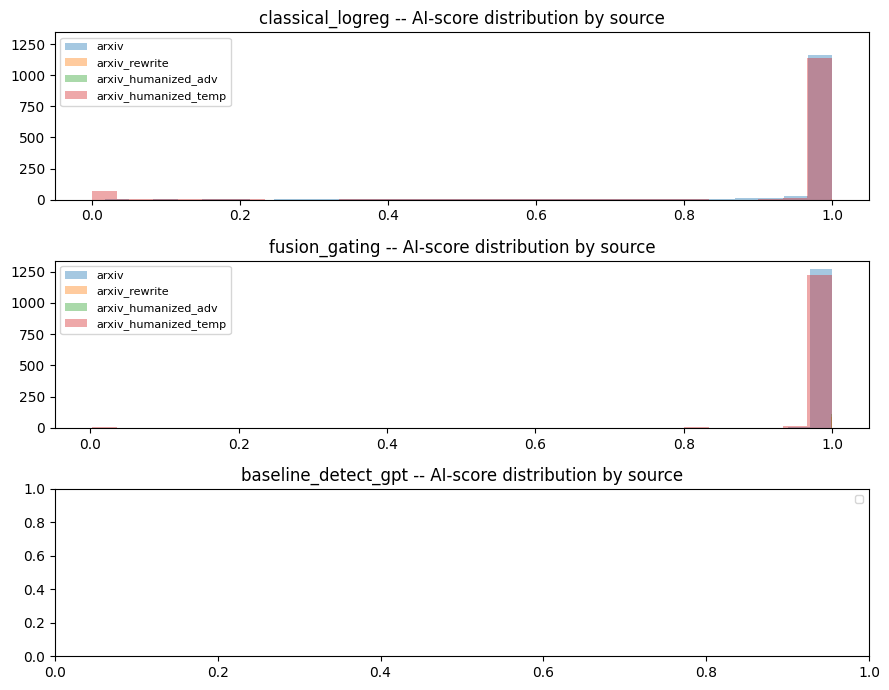

In [9]:
def _scores_by_source_in_house(ckpt_path, npz_path):
    """Return {source: scores} for one in-house checkpoint."""
    y, s, src = score_one(npz_path, ckpt_path)
    npz = np.load(npz_path, allow_pickle=True)
    sources = [str(x) for x in npz['sources']]
    out = {}
    for source in sorted(set(sources)):
        idx = [i for i, x in enumerate(sources) if x == source]
        out[source] = s[idx]
    return out

def _scores_by_source_baseline(detector_name, json_paths):
    """Concatenate scores from one or more baseline JSONs and split by `sources`."""
    all_s, all_src = [], []
    for p in json_paths:
        j = load_baseline(p)
        if j is None or len(j['y_scores']) == 0:
            continue
        all_s.extend(list(j['y_scores']))
        srcs = j.get('sources') or []
        if len(srcs) != len(j['y_scores']):
            srcs = ['(unknown)'] * len(j['y_scores'])
        all_src.extend([str(x) for x in srcs])
    arr = np.asarray(all_s)
    out = {}
    for source in sorted(set(all_src)):
        idx = [i for i, x in enumerate(all_src) if x == source]
        out[source] = arr[idx]
    return out

def _percentile_row(name, src_to_scores):
    rows = []
    for src in sorted(src_to_scores):
        arr = src_to_scores[src]
        if len(arr) == 0:
            continue
        rows.append({
            'detector': name, 'source': src, 'n': len(arr),
            'p10': float(np.percentile(arr, 10)),
            'p50': float(np.percentile(arr, 50)),
            'p90': float(np.percentile(arr, 90)),
            'mean': float(arr.mean()),
        })
    return rows

TOP3 = [
    ('classical_logreg',    MODELS_DIR / 'clf_logreg.joblib',   'in-house'),
    ('fusion_gating',       MODELS_DIR / 'fusion_gating.pt',    'in-house'),
    ('baseline_detect_gpt', None,                                'baseline'),
]
rows = []
for name, path, kind in TOP3:
    if kind == 'in-house':
        clean = _scores_by_source_in_house(path, ARXIV_NPZ_CLEAN)
        hum   = _scores_by_source_in_house(path, ARXIV_NPZ_HUM)
        combined = {**clean, **hum}
    else:
        combined = _scores_by_source_baseline(name, [
            BASE_CLEAN_DIR / 'arxiv_merged__detect_gpt.metrics.json',
            BASE_HUM_DIR / 'arxiv_eval_with_humanizers__detect_gpt.metrics.json',
        ])
    rows.extend(_percentile_row(name, combined))
df_dist = pd.DataFrame(rows).round(4)
print('=== AI-class score distribution percentiles, top-3 detectors x 4 sources ===')
display(df_dist)

# Optional histogram plot if matplotlib is available.
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=False)
    for ax, (name, path, kind) in zip(axes, TOP3):
        if kind == 'in-house':
            clean = _scores_by_source_in_house(path, ARXIV_NPZ_CLEAN)
            hum   = _scores_by_source_in_house(path, ARXIV_NPZ_HUM)
            combined = {**clean, **hum}
        else:
            combined = _scores_by_source_baseline(name, [
                BASE_CLEAN_DIR / 'arxiv_merged__detect_gpt.metrics.json',
                BASE_HUM_DIR / 'arxiv_eval_with_humanizers__detect_gpt.metrics.json',
            ])
        for src in ('arxiv', 'arxiv_rewrite', 'arxiv_humanized_adv', 'arxiv_humanized_temp'):
            if src in combined and len(combined[src]) > 0:
                ax.hist(combined[src], bins=30, alpha=0.4, label=src)
        ax.set_title(f'{name} -- AI-score distribution by source')
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
except Exception as e:
    print(f'(matplotlib not used: {e})')


## 8. Take-home for the OOD slice

**Ranking story.** The strongest clean-arxiv ranker is **`classical_logreg`** at AUC = 0.8946 ([`summary_clean.csv:10`](../test/results/arxiv_eval/summary_clean.csv)) — not the in-house fusion architecture. Among baselines, **`baseline_detect_gpt`** is second at AUC = 0.8276 ([`summary_clean.csv:3`](../test/results/arxiv_eval/summary_clean.csv); also visible in [`models/baseline_results/arxiv_clean/arxiv_merged__detect_gpt.metrics.json:10326`](baseline_results/arxiv_clean/arxiv_merged__detect_gpt.metrics.json)), even at the small-model GPT-2 + T5-small + N = 10 configuration ([`scripts/baselines_detect_gpt_local.json`](../scripts/baselines_detect_gpt_local.json)). **`fusion_gating`** is third at AUC = 0.8063 ([`summary_clean.csv:18`](../test/results/arxiv_eval/summary_clean.csv); 20 in the published REPORT table). Every other detector lands below AUC 0.75. The corollary is that the in-house gated fusion architecture, the principal methodological contribution of this project, is *not* the strongest detector on OOD academic prose — a linear classical baseline beats it by ~9 pp AUC.

**Humanizer story.** The §3.3 / §4 delta table shows three robustness regimes. (i) `fusion_gating` and `classical_random_forest_nela` both lose ~17 pp AUC under humanization — the fusion architecture is no more fragile than the single-modality NELA baseline, despite consuming three modalities. (ii) `baseline_detect_gpt` is the only baseline with a positive AUC delta under humanization (0.8276 → 0.8399); its per-source AI catch rises from 91.8 % on clean Claude-haiku rewrites to 96.3 % (Adv-P) / 95.6 % (Temp), per the JSON sources cited in §5. Perturbation-based methods *amplify* the local-log-probability signature when humanizers introduce extra stylistic distortions, the opposite of disguising it. (iii) `baseline_r_detect` collapses on TempParaphraser specifically (27 % AI catch vs. 73 % on Adv-P, [`arxiv_eval_with_humanizers__r_detect.metrics.json:15508,15512`](baseline_results/arxiv_humanized/arxiv_eval_with_humanizers__r_detect.metrics.json)) — kernel methods are uniquely vulnerable to content-distribution-preserving paraphrase while comparatively robust to adversarial-style-rewrite.

**Deployment story.** At strict FPR ≤ 1 %, no detector achieves > 33 % TPR on OOD academic prose with or without humanizers, and most achieve < 10 %. The top-line strict-FPR macro-F1s on clean arxiv are `classical_mlp` 0.652 and `classical_logreg` 0.519 ([`summary_clean.csv:11,10`](../test/results/arxiv_eval/summary_clean.csv)); on humanized arxiv the corresponding numbers are 0.728 and 0.539 ([`summary_humanized.csv:11,10`](../test/results/arxiv_eval/summary_humanized.csv)). The `classical_mlp` humanized gain is a class-prior-alignment artefact, not a robustness signal (see §4). At deployment-grade operating points the detector arms race is structurally on the losing side — the methodological contribution of this work is to quantify *how* badly, and to identify which detector families pay which kind of tax under which humanizer attack.